# Relative L² Error: SA‑PINN‑DivType vs. Kurganov–Tadmor
### Compares the divergence‑type PINN predictions with the converged KT solution.

Grids differ: remapping KT → PINN grid …
Relative L²(n) over spacetime = 8.500815e-03
Relative L²(q) over spacetime = 6.718195e-02
[saved] ./L2_results_DivType.txt


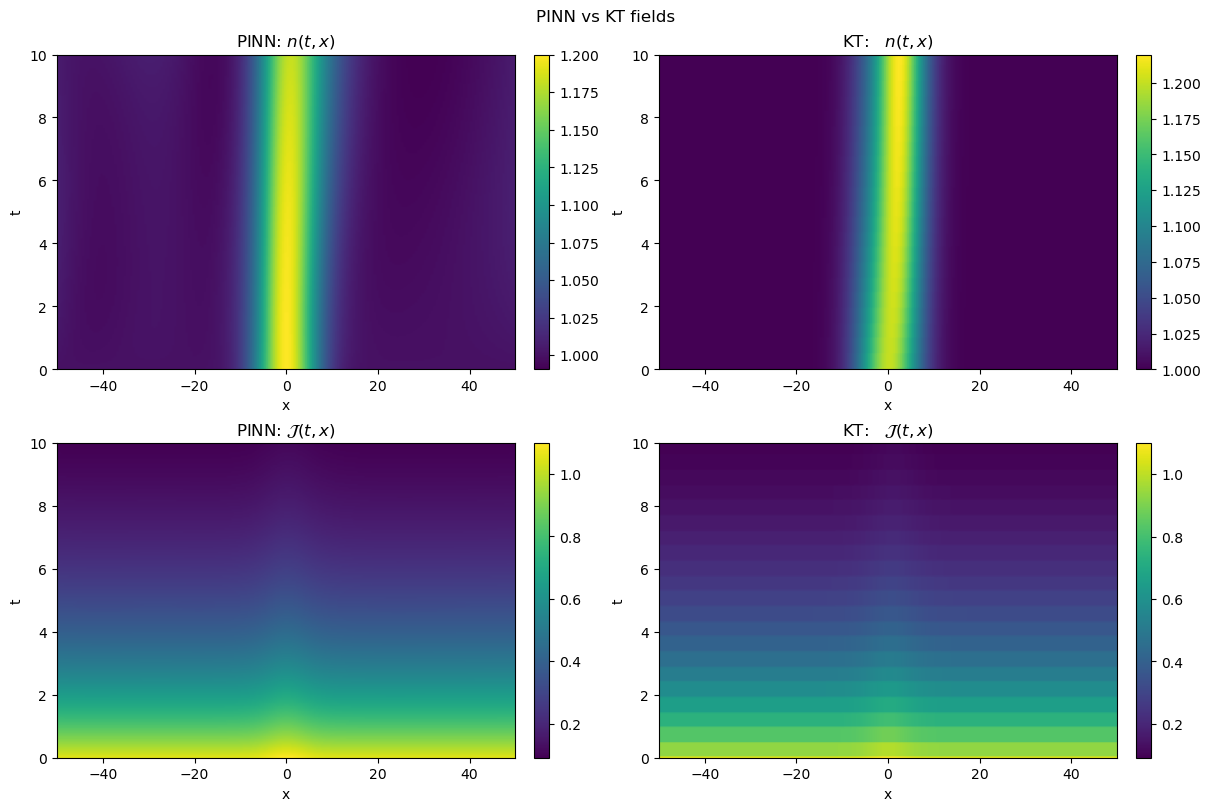

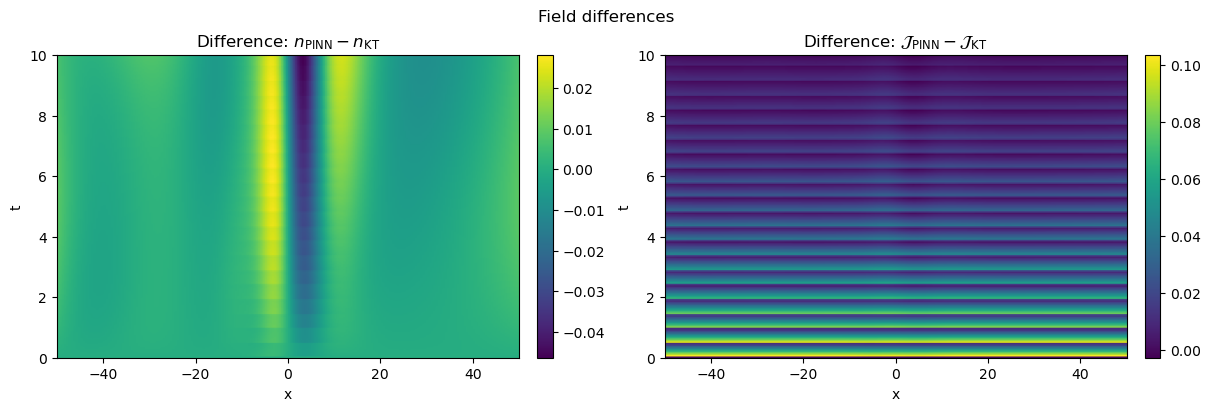

[saved] plots/setup_1/PINN_vs_KT.pdf
[saved] plots/setup_1/Field_differences.pdf


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

base_dir = "plots"
folder = os.path.join(base_dir, "setup_1")
os.makedirs(folder, exist_ok=True)

# ---------- load data ----------
pinn_data = np.load("./pinn_runs/divtype_pinn_20260611_181021.npz", allow_pickle=True)
kt_data   = np.load("./KT_DivType/snapshots.npz")

t_pinn = pinn_data["t_eval"].astype(np.float64)
x_pinn = pinn_data["x_eval"].astype(np.float64)
t_kt   = kt_data["t"].astype(np.float64)
x_kt   = kt_data["x"].astype(np.float64)

n_pinn   = pinn_data["n"].astype(np.float64)
q_pinn   = pinn_data["q"].astype(np.float64)
n_kt     = kt_data["n"].astype(np.float64)
q_kt     = kt_data["q"].astype(np.float64)

L = float(kt_data.get("L", pinn_data.get("L", 50.0)))

# ---------- interpolation helpers ----------
def periodic_interp_space_vec(x_src, Ytx, x_q, L):
    x_ext = np.concatenate([x_src - 2*L, x_src, x_src + 2*L])
    out = np.empty((Ytx.shape[0], x_q.size), dtype=np.float64)
    xq = ((x_q + L) % (2*L)) - L
    for it in range(Ytx.shape[0]):
        y_ext = np.concatenate([Ytx[it], Ytx[it], Ytx[it]])
        out[it] = np.interp(xq, x_ext, y_ext)
    return out

def interp_time_vec(t_src, Ytx, t_q):
    Nt_q, Nx = t_q.size, Ytx.shape[1]
    out = np.empty((Nt_q, Nx), dtype=np.float64)
    for j in range(Nx):
        out[:, j] = np.interp(t_q, t_src, Ytx[:, j])
    return out

def remap_to_grid(t_src, x_src, Ytx, t_dst, x_dst, L):
    Y_t = interp_time_vec(t_src, Ytx, t_dst)
    Y_x = periodic_interp_space_vec(x_src, Y_t, x_dst, L)
    return Y_x

# ---------- remap KT to PINN grid (if different) ----------
# Compare shapes and values up to the common length
same_t = (len(t_kt) == len(t_pinn)) and np.allclose(t_kt, t_pinn)
same_x = (len(x_kt) == len(x_pinn)) and np.allclose(x_kt, x_pinn)

if same_t and same_x:
    n_kt_on_p = n_kt
    q_kt_on_p = q_kt
else:
    print("Grids differ: remapping KT → PINN grid …")
    n_kt_on_p = remap_to_grid(t_kt, x_kt, n_kt, t_pinn, x_pinn, L)
    q_kt_on_p = remap_to_grid(t_kt, x_kt, q_kt, t_pinn, x_pinn, L)

# ---------- relative L² error ----------
dx = (x_pinn[-1] - x_pinn[0]) / (x_pinn.size - 1)
dt = (t_pinn[-1] - t_pinn[0]) / (t_pinn.size - 1)

def rel_l2(u_pinn, u_kt, dx, dt):
    num = np.sqrt(np.sum((u_pinn - u_kt)**2) * dx * dt)
    den = np.sqrt(np.sum(u_kt**2) * dx * dt)
    return 0.0 if den == 0.0 else num / den

Erel_n = rel_l2(n_pinn, n_kt_on_p, dx, dt)
Erel_q = rel_l2(q_pinn, q_kt_on_p, dx, dt)

print(f"Relative L²(n) over spacetime = {Erel_n:.6e}")
print(f"Relative L²(q) over spacetime = {Erel_q:.6e}")

# Save text report
save_path = "./L2_results_DivType.txt"
with open(save_path, "w") as f:
    f.write(f"Relative L2(n) = {Erel_n:.6e}\n")
    f.write(f"Relative L2(q) = {Erel_q:.6e}\n")
print(f"[saved] {save_path}")

# ---------- heatmap helper ----------
def heat(ax, Z, title, t_axis, x_axis):
    im = ax.imshow(
        Z, origin="lower",
        extent=[x_axis[0], x_axis[-1], t_axis[0], t_axis[-1]],
        aspect="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ---------- plots ----------
# Comparison figure
fig1, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
heat(axs[0,0], n_pinn,        r"PINN: $n(t,x)$",          t_pinn, x_pinn)
heat(axs[0,1], n_kt_on_p,     r"KT:   $n(t,x)$",          t_pinn, x_pinn)
heat(axs[1,0], q_pinn,        r"PINN: $\mathcal{J}(t,x)$", t_pinn, x_pinn)
heat(axs[1,1], q_kt_on_p,     r"KT:   $\mathcal{J}(t,x)$", t_pinn, x_pinn)
plt.suptitle("PINN vs KT fields")
fig1_path = os.path.join(folder, "PINN_vs_KT.pdf")
plt.savefig(fig1_path, dpi=300)
plt.show()

# Difference figure
fig2, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
heat(axs[0], n_pinn - n_kt_on_p,
     r"Difference: $n_{\rm PINN} - n_{\rm KT}$", t_pinn, x_pinn)
heat(axs[1], q_pinn - q_kt_on_p,
     r"Difference: $\mathcal{J}_{\rm PINN} - \mathcal{J}_{\rm KT}$", t_pinn, x_pinn)
plt.suptitle("Field differences")
fig2_path = os.path.join(folder, "Field_differences.pdf")
plt.savefig(fig2_path, dpi=300)
plt.show()

print(f"[saved] {fig1_path}")
print(f"[saved] {fig2_path}")